# Running Palace Simulations

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on an integrated RF transformer, extracting the broadband S-parameters to evaluate differential performance metrics such as insertion loss and impedance matching.

**Requirements:**
- IHP PDK: `uv pip install ihp-gdsfactory`
- gsim with Palace backend

In [1]:
import math

import gdsfactory as gf
from gdsfactory import Component
from gdsfactory.typings import LayerSpec, LayerSpecs
from ihp import PDK

PDK.activate()

### Build transformer

In [2]:
def secondary_inductor(
    width: float = 3.0,
    space: float = 3.1,
    diameter: float = 50.0,
    layer_metal: LayerSpec = "TopMetal2drawing",
    layer_metal_name: str = "TopMetal2",
    layer_jumper: LayerSpec = "TopMetal1drawing",
    layer_jumper_name: str = "TopMetal1",
    via_size: float = 1.5,
) -> Component:
    w = width
    s = space
    d = diameter

    r = d / 2 + s
    octagon_center_y = 3 * r
    pi_over_4 = math.radians(45)

    path_points = [(+space / 2, octagon_center_y - r * math.cos(pi_over_4 / 2))]
    for i in range(-2, 6):
        angle = i * pi_over_4 + pi_over_4 / 2
        r = d / 2 + s
        x = r * math.cos(angle)
        y = r * math.sin(angle) + octagon_center_y
        path_points.append((x, y))
    path_points.append((-space / 2, octagon_center_y - r * math.cos(pi_over_4 / 2)))

    gap_y = octagon_center_y - r * math.cos(pi_over_4 / 2)

    path = gf.Path(path_points)
    c = gf.path.extrude(path, layer=layer_metal, width=w)

    length = 2 * r + s

    lead1 = c << gf.components.rectangle(size=(s, length), layer=layer_jumper)
    lead1.move((-s - s / 2, 0))
    c.add_port(name="P1", center=(-s, s), width=s, orientation=270, layer=layer_jumper)

    lead2 = c << gf.components.rectangle(size=(s, length), layer=layer_jumper)
    lead2.move((s - s / 2, 0))
    c.add_port(name="P2", center=(s, s), width=s, orientation=270, layer=layer_jumper)

    via_stack_component = gf.get_component(
        "via_stack",
        bottom_layer=layer_jumper_name,
        top_layer=layer_metal_name,
        size=(via_size, via_size),
        vn_columns=1,
        vn_rows=1,
    )
    junction1 = c.add_ref(via_stack_component)
    junction1.move(junction1.center, (-space, gap_y))
    junction2 = c.add_ref(via_stack_component)
    junction2.move(junction2.center, (space, gap_y))

    c.flatten()
    return c

In [3]:
@gf.cell
def transformer_concentric(
    width_primary: float = 3.0,
    width_secondary: float = 3.0,
    space: float = 3.1,
    coupling_gap: float = 4.0,
    diameter_outer: float = 80.0,
    layer: LayerSpec = "TopMetal2drawing",
    layer_name: str = "TopMetal2",
    jumper_layer: LayerSpec = "TopMetal1drawing",
    jumper_bottom_layer_name: str = "TopMetal1",
    via_size: float | None = None,
    layer_inductor: LayerSpec = "INDdrawing",
    layers_no_fill: LayerSpecs = ("NoMetFillerdrawing",),
) -> Component:
    """Concentric, coplanar 1:1 transformer (single-turn coils).

    Primary: standard gf.components.inductor(), outer ring, on `layer`.
    Secondary: same octagonal spiral, inner ring, but its leads are drawn
    on `jumper_layer` (TopMetal1) instead of `layer`, so they pass
    underneath the primary ring without colliding. A via_stack connects
    each lead to the coil body right where they meet, then the lead runs
    on jumper_layer straight out past the primary's outer edge.

    Returns:
        Component with ports P1, P2 (primary, on layer) and
        S1, S2 (secondary, on jumper_layer).
    """
    c = gf.Component()
    via_size = via_size or width_secondary

    # Primary coil (outer ring), standard inductor
    primary = gf.components.inductor(
        width=width_primary,
        space=space,
        diameter=diameter_outer,
        turns=1,
        layer_metal=layer,
        layer_inductor=layer_inductor,
        layer_metal_pin=layer,
        layers_no_fill=layers_no_fill,
    )
    prim_ref = c.add_ref(primary)
    cx, cy = prim_ref.center
    prim_ref.move((-cx, -cy))

    # Compute inner diameter for secondary
    diameter_secondary = diameter_outer - 2 * (width_primary + space) - 2 * coupling_gap

    # Secondary coil geometry
    w = width_secondary
    s = space
    d = diameter_secondary

    r = d / 2 + s
    octagon_center_y = 3 * r
    pi_over_4 = math.radians(45)

    path_points = [(+space / 2, octagon_center_y - r * math.cos(pi_over_4 / 2))]
    for i in range(-2, 6):
        angle = i * pi_over_4 + pi_over_4 / 2
        r = d / 2 + s
        x = r * math.cos(angle)
        y = r * math.sin(angle) + octagon_center_y
        path_points.append((x, y))
    path_points.append((-space / 2, octagon_center_y - r * math.cos(pi_over_4 / 2)))

    # This is the actual gap where the coil is open — the real
    # junction point between the coil body and each lead
    gap_y = octagon_center_y - r * math.cos(pi_over_4 / 2)

    path = gf.Path(path_points)
    secondary = gf.path.extrude(path, layer=layer, width=w)

    length = 2 * r + s

    lead1 = secondary << gf.components.rectangle(size=(s, length), layer=jumper_layer)
    lead1.move((-s - s / 2, 0))
    lead2 = secondary << gf.components.rectangle(size=(s, length), layer=jumper_layer)
    lead2.move((s - s / 2, 0))

    # Connect coil body (layer) to each lead (jumper_layer)
    via_stack_component = gf.get_component(
        "via_stack",
        bottom_layer=jumper_bottom_layer_name,
        top_layer=layer_name,
        size=(via_size, via_size),
    )
    junction1 = secondary.add_ref(via_stack_component)
    junction1.move(junction1.center, (-space, gap_y))
    junction2 = secondary.add_ref(via_stack_component)
    junction2.move(junction2.center, (space, gap_y))

    # External ports on jumper_layer
    secondary.add_port(
        name="S1", center=(-s, s), width=s, orientation=90, layer=jumper_layer
    )
    secondary.add_port(
        name="S2", center=(s, s), width=s, orientation=90, layer=jumper_layer
    )

    # IND marker layer
    outer_polygon_pts = []
    for i in range(8):
        r_outer = (d / 2 + length) / (math.cos(pi_over_4 / 2))
        angle = i * pi_over_4 + pi_over_4 / 2
        x = r_outer * math.cos(angle)
        y = r_outer * math.sin(angle) + octagon_center_y
        outer_polygon_pts.append((x, y))
    secondary.add_polygon(points=outer_polygon_pts, layer=layer_inductor)

    sec_ref = c.add_ref(secondary)
    sec_ref.rotate(180)
    cx, cy = sec_ref.center
    sec_ref.move((-cx, -cy))

    # Expose all 4 ports
    c.add_port(name="P1", port=prim_ref.ports["P1"])
    c.add_port(name="P2", port=prim_ref.ports["P2"])
    c.add_port(name="S1", port=sec_ref.ports["S1"])
    c.add_port(name="S2", port=sec_ref.ports["S2"])

    c.flatten()
    return c

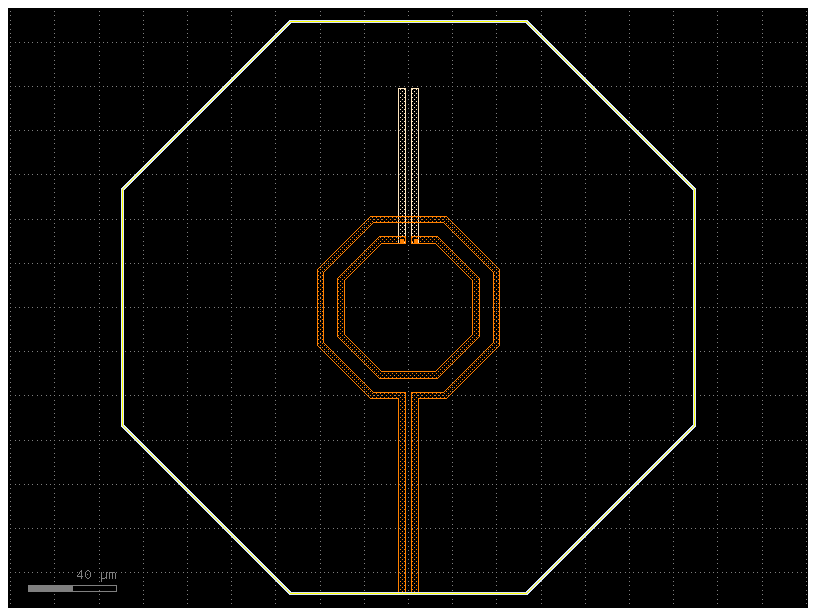

In [4]:
c = transformer_concentric()
c.plot()

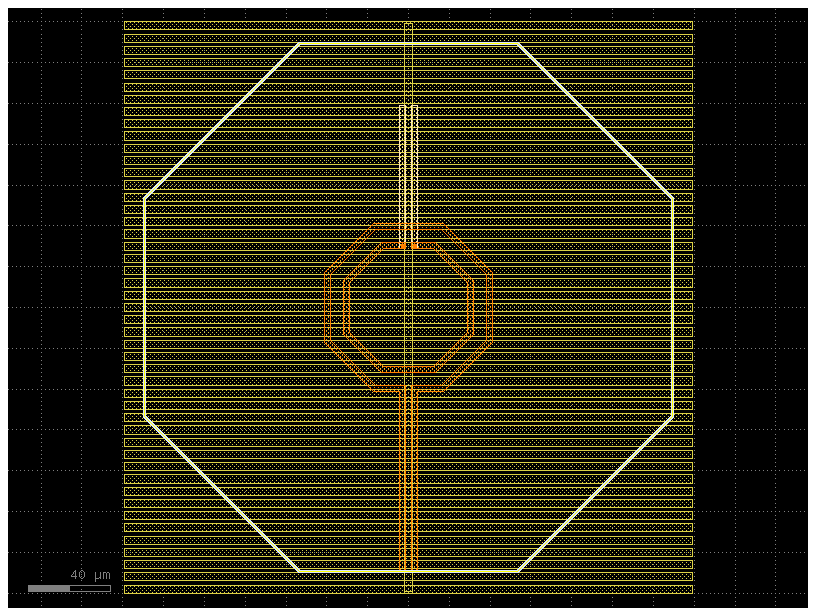

In [5]:
def add_pgs_to_transformer(
    c: gf.Component,
    margin: float = 5.0,
    w: float = 2.0,
    s: float = 2.0,
    layer="Metal5drawing",
):
    bbox = c.bbox()

    # Calculate center manually
    cx = (bbox.left + bbox.right) / 2
    cy = (bbox.bottom + bbox.top) / 2

    # Shield boundaries (Padded)
    xmin, xmax = bbox.left - margin, bbox.right + margin
    ymin, ymax = bbox.bottom - margin, bbox.top + margin

    # 1. Central vertical spine
    c.add_polygon(
        [
            (-w / 2 + cx, ymin),
            (-w / 2 + cx, ymax),
            (w / 2 + cx, ymax),
            (w / 2 + cx, ymin),
        ],
        layer=layer,
    )

    # 2. Horizontal fingers
    pitch = w + s
    total_height = ymax - ymin
    num_fingers = math.floor(total_height / pitch)

    for i in range(-num_fingers // 2, num_fingers // 2 + 1):
        yc = cy + (i * pitch)
        c.add_polygon(
            [
                (xmin, yc - w / 2),
                (xmin, yc + w / 2),
                (xmax, yc + w / 2),
                (xmax, yc - w / 2),
            ],
            layer=layer,
        )


cc = c.copy()
add_pgs_to_transformer(cc, margin=10.0, w=4.0, s=2.0)

cc.plot()

### Configure and run simulation with DrivenSim

In [6]:
from gsim.palace import DrivenSim

sim = DrivenSim()
sim.set_output_dir("./palace-sim-transformer-concentric")
sim.set_geometry(cc)
sim.set_stack(substrate_thickness=180.0, include_substrate=True)

# P1, P2 -> primary coil, on TopMetal2
sim.add_port(
    "P1", from_layer="metal5", to_layer="topmetal2", geometry="via", excited=True
)
sim.add_port(
    "P2", from_layer="metal5", to_layer="topmetal2", geometry="via", excited=True
)

# S1, S" -> secondary coil, same layer as primary
sim.add_port(
    "S1", from_layer="metal5", to_layer="topmetal1", geometry="via", excited=True
)

sim.add_port(
    "S2", from_layer="metal5", to_layer="topmetal1", geometry="via", excited=True
)

sim.set_driven(fmin=10e9, fmax=100e9, num_points=60)
print(sim.validate_config())

Validation: PASSED


In [7]:
# Generate mesh (presets: "coarse", "default", "fine")
sim.set_airbox(margin_x=50, margin_y=50, z_above=50, z_below=5)
sim.mesh(preset="default", refined_mesh_size=3)
sim.write_config()

Small conductor feature detected (2.000 um) may be under-resolved by refined_mesh_size=5.000 um. Pass auto_size=True to scale the mesh down.


Info    : Reading 'palace-sim-transformer-concentric/palace.msh'...
Info    : 45594 nodes
Info    : 341778 elements
Info    : Done reading 'palace-sim-transformer-concentric/palace.msh'                                            
Info    : Reading 'palace-sim-transformer-concentric/palace.msh'...
Info    : 45594 nodes
Info    : 341778 elements
Info    : Done reading 'palace-sim-transformer-concentric/palace.msh'                                            
Info    : Reading 'palace-sim-transformer-concentric/palace.msh'...
Info    : 45594 nodes
Info    : 341778 elements
Info    : Done reading 'palace-sim-transformer-concentric/palace.msh'                                            
Info    : Reading 'palace-sim-transformer-concentric/palace.msh'...
Info    : 45594 nodes
Info    : 341778 elements
Info    : Done reading 'palace-sim-transformer-concentric/palace.msh'                                            


PosixPath('palace-sim-transformer-concentric/config.json')

In [38]:
sim.plot_mesh(show_groups=["metal", "P", "via"])

Widget(value='<iframe src="http://localhost:38725/index.html?ui=P_0x73cc2a99f590_2&reconnect=auto" class="pyvi…

In [39]:
sim.plot_mesh(
    style="solid",
    transparent_groups=["air__None", "sio2__None", "air__sio2"],
)

Widget(value='<iframe src="http://localhost:38725/index.html?ui=P_0x73cc2a99f650_3&reconnect=auto" class="pyvi…

### Run simulation on cloud

In [10]:
# Run simulation on GDSFactory+ cloud
results = sim.run()

  palace-bb87edac  completed  16m 07s
Extracting results.tar.gz...
Downloaded 10 files to /home/delfi/Documents/gsim/nbs/sim-data-palace-bb87edac


In [11]:
results.plot_interactive()

Port mapping: Port 1: P1, Port 2: P2, Port 3: S1, Port 4: S2


In [12]:
results.plot_interactive(phase=True)

Port mapping: Port 1: P1, Port 2: P2, Port 3: S1, Port 4: S2


### S- and Z-parameters from the Palace simulation

`results` currently holds the raw per-port-pair S-parameters returned by Palace. To compare against the lumped-element model later, we load them into an `skrf.Network`, which gives us the S-parameter matrix at every frequency point and lets us derive the corresponding Z-parameters (`ntwk.z`) directly. These are the **EM-simulated** S/Z-parameters of the actual `gdsfactory` layout.

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf

freq_scale = 1e9
f = results.freq * freq_scale
w = 2 * np.pi * f

ports = results.port_names
n = len(ports)

S = np.zeros((len(f), n, n), dtype=complex)
for i, pi in enumerate(ports):
    for j, pj in enumerate(ports):
        S[:, i, j] = results[(pi, pj)].complex

ntwk = rf.Network(f=f, s=S, f_unit="hz")
Z = ntwk.z
Y = ntwk.y

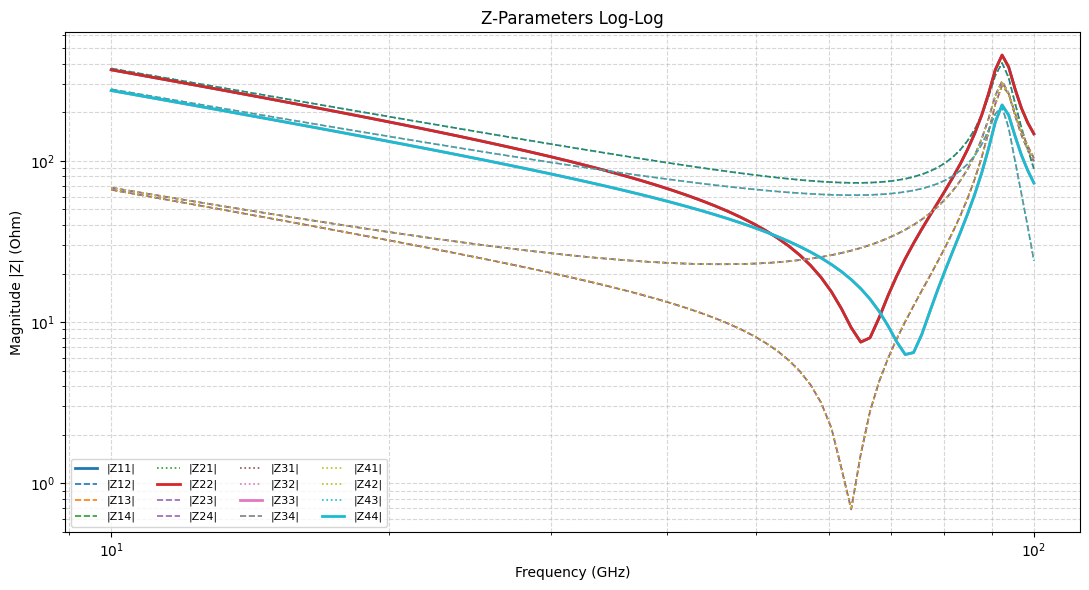

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))
cmap = plt.cm.tab10
colors = [cmap(k) for k in np.linspace(0, 1, n * n)]

idx = 0
for i in range(n):
    for j in range(n):
        label = f"|Z{i + 1}{j + 1}|"
        ls = "-" if i == j else ("--" if i < j else ":")

        ax.plot(
            f / 1e9,
            np.abs(Z[:, i, j]),
            label=label,
            linestyle=ls,
            linewidth=2 if i == j else 1.2,
            color=colors[idx],
        )
        idx += 1

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Magnitude |Z| (Ohm)")
ax.set_title("Z-Parameters Log-Log")
ax.legend(ncol=n, fontsize=8)
ax.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

## From EM simulation to a compact circuit model

The Palace simulation above gives accurate broadband S/Z-parameters for the physical `transformer_concentric` layout, but it treats the device as a black box: a full 3-D field solve is needed for every geometry variant, and there is no direct handle on physically meaningful quantities like the primary/secondary self-inductance or the coupling coefficient $\kappa$.

To get that handle, we build a compact lumped-element model of the transformer — self-inductances $L_1, L_2$, mutual inductance $M$, and parasitic series resistance/shunt capacitance — using [`circulax`](https://github.com/), a JAX-based circuit simulator. Once this model reproduces the Palace S/Z-parameters, its parameters *are* the extracted electrical characteristics of the layout, and being written in JAX, the model is differentiable and can later be used to fit those parameters directly against the EM data (or the layout can be optimized against a target circuit response).

The rest of this notebook: (1) defines a `Transformer` component for `circulax`, (2) assembles it into a netlist with the fitted parasitics, and (3) computes its S/Z-parameters the same way as above, so the two can be compared side by side.

In [69]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

## Mathematical Modeling of a Transformer

To accurately define a transformer for a circuit solver, we must bridge the gap between fundamental electromagnetism, the algebraic constraints required by software components, and the physical realities of high-frequency circuits.

### From Physical Laws to Software Constraints
To understand inductive coupling, let's recall how inductors work. For a simple coil in a vacuum carrying a current $I$, Ampere's law dictates that a magnetic field $B \propto I$ is created. If the current changes, the field varies, and according to Faraday's law, an electric field $E \propto dB/dt$ is generated.

The total voltage drop across the terminals of the inductor results from integrating this electric field along the coil, evaluated using Stokes' Theorem:
$$\Delta V = \oint \mathbf{E} \cdot d\mathbf{l} = - \frac{d}{dt} \iint \mathbf{B} \cdot d\mathbf{S} = - \frac{d\Phi}{dt}$$
where $\Phi$ is the magnetic flux. Because $\Phi$ is proportional to $I$, we define the proportionality constant as the inductance, $L$. This gives the typical circuit behavior:
$$\Delta V = -L \, \frac{dI}{dt}$$

Circuit simulators compute instantaneous balance equations by separating variables into instantaneous values (**flows**, like KCL currents) and time-dependent quantities (**storage**, like flux). To map the physics above into algebraic constraints for a solver, we rely directly on the flux ($\Phi$) formulation:
* **Flow constraints:** The true current is set at the ports ($i_L = i_{p1} = -i_{p2}$), and the port voltage drop $v_{drop}$ is temporarily equated to the current state variable.
* **Storage constraints:** The time derivative of the flux is evaluated as $-L \cdot i_L$. The solver differentiates this with respect to time to compute $d\Phi/dt$, satisfying our fundamental voltage equation.

### Mutual Inductance and Impedance
We can extend these definitions to a general case where two inductors are close to each other. The magnetic field created by one coil contributes to the magnetic flux enclosed by the other. If $\Phi_{jk}$ is the flux at the $j$-th inductor when a current $I_k$ flows through the $k$-th inductor, the total flux by linearity is:
$$\Phi_j = \sum_k \Phi_{jk} = \sum_k L_{jk} I_k$$
This defines the mutual inductance matrix $\mathbf{L}$. From this symmetric matrix, we can express the off-diagonal terms in terms of self-inductances ($L_{jj}, L_{kk}$) to define a geometric coupling constant $\kappa$:
$$\kappa_{jk} = \frac{L_{jk}}{\sqrt{L_{jj} L_{kk}}}, \qquad |\kappa_{jk}| \leq 1$$

When coils are coupled ($M \neq 0$), the effective input impedance depends on the secondary side impedance ($Z_2$) due to the coupling term in Kirchhoff's Voltage Laws:
$$V_1 = j \omega \, L_1 \, i_1 + j \omega \, M \, i_2$$
$$0 = j \omega M \, i_1 + (j \omega \,L_2 + Z_2) \, i_2$$

From these KVLs, we derive the current ratio:
$$\frac{i_2}{i_1} = - \frac{j \omega M}{j \omega \,L_2 + Z_2} = -\sqrt{\frac{L_1}{L_2}}\,\frac{\kappa}{1+Z_2/(j\omega L_2)}$$

This yields the equivalent **input impedance ($Z_{11}$)**:
$$Z_{11} = \frac{V_1}{i_1} = j \omega \, L_1  \left( 1-\frac{\kappa^2}{1+Z_2/(j\omega L_2)} \right)$$

If an external current $i_2'$ is injected into the secondary loop, it splits between the load $Z_2$ and the secondary coil $L_2$. Using symmetric expressions, we find the **output impedance ($Z_{22}$)**:
$$Z_{22} = j \omega \, L_2  \left( 1-\frac{\kappa^2}{1+Z_1/(j\omega L_1)} \right)$$

And we determine the overall **transimpedance ($Z_{12}$)**:
$$Z_{12} = \frac{V_1}{i_2'} = -Z_1 \frac{i_1}{i_2} \, \left( \frac{Z_{22}}{Z_2} - 1\right)$$

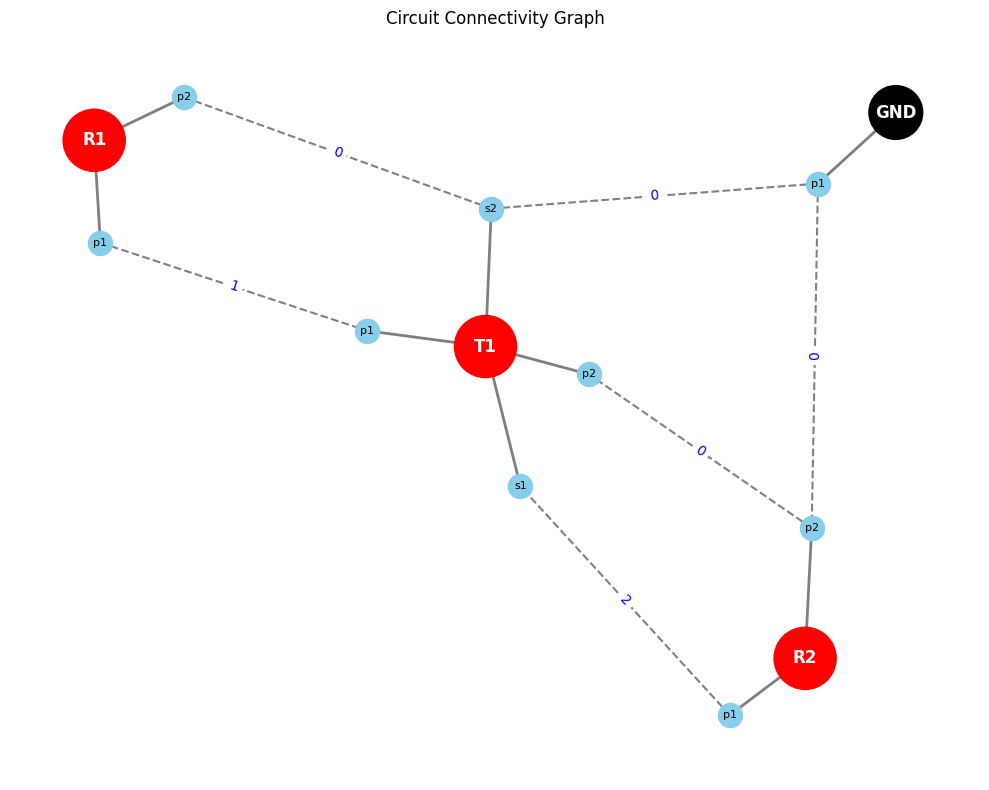

/tmp/ipykernel_192958/3869806952.py:72: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  graph.show()


In [ ]:
from circulax import compile_circuit
from circulax.components.base_component import Signals, States, component
from circulax.components.electronic import Capacitor, Inductor, Resistor
from circulax.netlist import draw_circuit_graph

# primary coil: L1 between p1,p2
# secondary coil: L2 between s1,s2
# with mutual inductance M


@component(ports=("p1", "p2", "s1", "s2"), states=("i_L1", "i_L2"))
def transformer(
    signals: Signals, s: States, L1: float = 1e-9, L2: float = 1e-9, M: float = 0.0
):
    """Two inductively coupled coils: primary (p1, p2), secondary (s1, s2).

    Flux linkage:  phi1 = L1*i_L1 + M*i_L2
                   phi2 = M*i_L1 + L2*i_L2
    so that        V1 = d(phi1)/dt,  V2 = d(phi2)/dt
    """
    v1 = signals.p1 - signals.p2
    v2 = signals.s1 - signals.s2
    f_dict = {
        "p1": s.i_L1,
        "p2": -s.i_L1,
        "s1": s.i_L2,
        "s2": -s.i_L2,
        "i_L1": v1,
        "i_L2": v2,
    }
    q_dict = {
        "i_L1": -(L1 * s.i_L1 + M * s.i_L2),
        "i_L2": -(M * s.i_L1 + L2 * s.i_L2),
    }
    return f_dict, q_dict


# define characteristic impedance
Z0 = 50

# test circuit netlist
net_dict = {
    "instances": {
        # ground
        "GND": {"component": "ground"},
        # ideal transformer
        "T1": {
            "component": "transformer",
            "settings": {"L1": 1e-3, "L2": 1e-3, "M": 0.0},
        },
        # shunt resistance
        "R1": {"component": "resistor", "settings": {"R": Z0}},
        "R2": {"component": "resistor", "settings": {"R": Z0}},
    },
    "connections": {
        # node 0
        "GND,p1": ("T1,p2", "T1,s2", "R1,p2", "R2,p2"),
        # node 1
        "R1,p1": "T1,p1",
        # node 2
        "R2,p1": "T1,s1",
    },
}

# component definitions
# (Note: Resistor and compile_circuit must be imported from circulax in your environment)
models = {
    "resistor": Resistor,
    "transformer": transformer,
    "ground": lambda: 0,
}

# compile and visualize
circuit = compile_circuit(net_dict, models)
graph = draw_circuit_graph(netlist=net_dict)
graph.set_size_inches(6, 6)
graph.show()

### The Full Non-Ideal Model
The equations above perfectly describe ideal mathematical coupling, but real coils are not made of perfect conductors or isolated in a vacuum. To define a realistic transformer for the solver, we take the mathematically perfect core component and embed it within a macroscopic circuit of parasitic elements.

The complete non-ideal model introduces the following physical constraints:
* **Series Resistance ($R_{1,2}$):** Because the electric path exhibits a finite ohmic resistance $R_L$, we place resistors in series with the coils (e.g., $5\,\Omega$).
* **Parasitic Capacitance ($C_{1,2}$):** The physical proximity between wire loops or electric lines creates parasitic capacitance $C$, modeled as parallel capacitors (e.g., $7\text{ fF}$).
* **Dielectric Loss ($R_{3,4}$):** Electric field variations in the surrounding dielectric medium produce further energy losses. This is modeled as an additional parallel resistor. To ensure the parasitic capacitance remains mostly reactive, this value is kept much smaller than the capacitive reactance: $R_{3,4} \ll 1/(\omega_0 C)$.

By layering these physical parasitic components around the ideal flux-coupled core, the software model accurately reflects the resonances and high-frequency roll-offs of a real-world transformer.

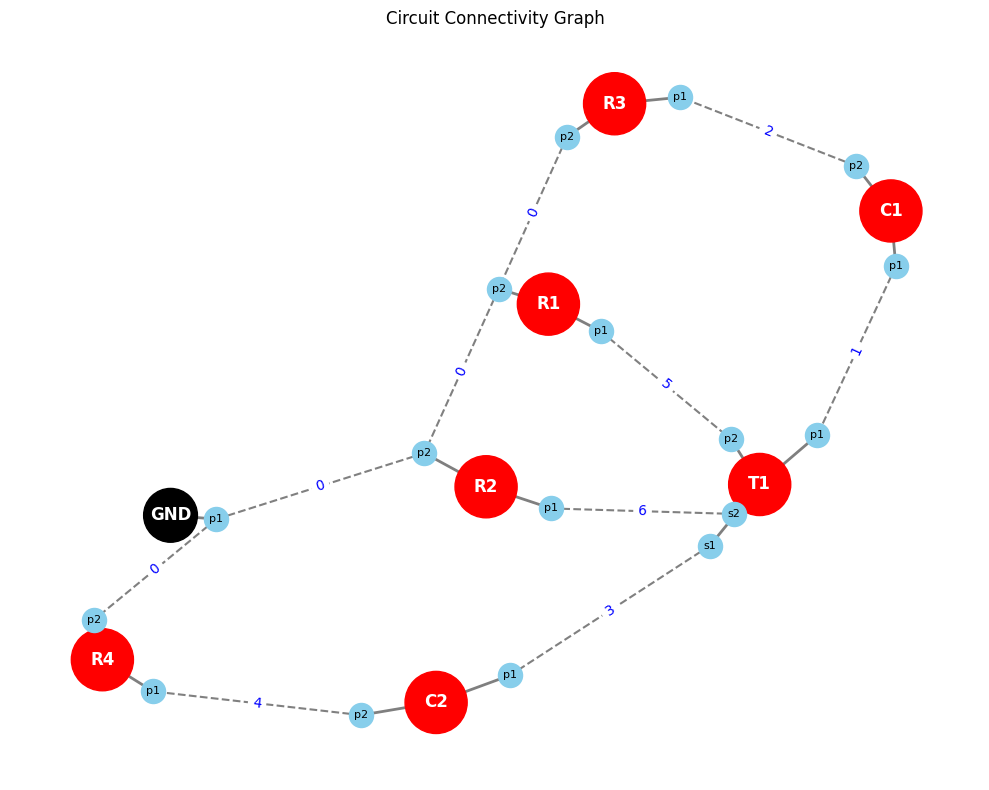

/tmp/ipykernel_192958/1899909004.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  graph.show()


In [71]:
Rs = 5
L = 120e-12
C = 7e-15
Rp = 0.05 / (2 * jnp.pi * jnp.sqrt(L / C))
k = 0.9

sim_transf = {
    "instances": {
        # ground
        "GND": {"component": "ground"},
        # transformer
        "T1": {"component": "transformer", "settings": {"L1": L, "L2": L, "M": k * L}},
        # parallel capacitance
        "C1": {"component": "capacitor", "settings": {"C": C}},
        "C2": {"component": "capacitor", "settings": {"C": C}},
        # series resistance
        "R1": {"component": "resistor", "settings": {"R": Rs}},
        "R2": {"component": "resistor", "settings": {"R": Rs}},
        # dielectric losses
        "R3": {"component": "resistor", "settings": {"R": Rp}},
        "R4": {"component": "resistor", "settings": {"R": Rp}},
    },
    "connections": {
        # node 0
        "GND,p1": ("R1,p2", "R2,p2", "R3,p2", "R4,p2"),
        # primary side
        "R1,p1": "T1,p2",
        "R3,p1": "C1,p2",
        "C1,p1": "T1,p1",  # secondary
        "R2,p1": "T1,s2",
        "R4,p1": "C2,p2",
        "C2,p1": "T1,s1",
    },
}

# component definitions
models = {
    "resistor": Resistor,
    "capacitor": Capacitor,
    "transformer": transformer,
    "ground": lambda: 0,
}

circuit = compile_circuit(sim_transf, models)
graph = draw_circuit_graph(netlist=sim_transf)
graph.set_size_inches(6, 6)
graph.show()

### Evaluating the full non-ideal model

With the lumped-element parasitic circuit compiled, we run a broadband AC sweep to evaluate its real-world high-frequency behavior. Just as we would with lab measurements or physical EM data, we first establish the DC operating point and then sweep the frequency from $1\text{ GHz}$ to $1\text{ THz}$. We extract the S-parameters at the primary and secondary ports to measure power transmission and reflection, and then convert them into Z-parameters. This allows us to map the raw impedance and visually identify the self-resonant frequencies where parasitic capacitance and physical losses overtake the ideal transformer behavior.

In [72]:
from circulax import setup_ac_sweep

# evaluate dc point
y_dc = circuit()

# select port nodes
port_nodes = [circuit.port_map["T1,p1"], circuit.port_map["T1,s1"]]

# setup ac sweep
run_ac = setup_ac_sweep(circuit.groups, circuit.sys_size, port_nodes, z0=Z0)

# choose target frequencies
freqs = jnp.logspace(9, 12, 61)  # 1 GHz to 1 THz

# evaluate S parameters
S = run_ac(y_dc, freqs)

#### Plot S-parameters

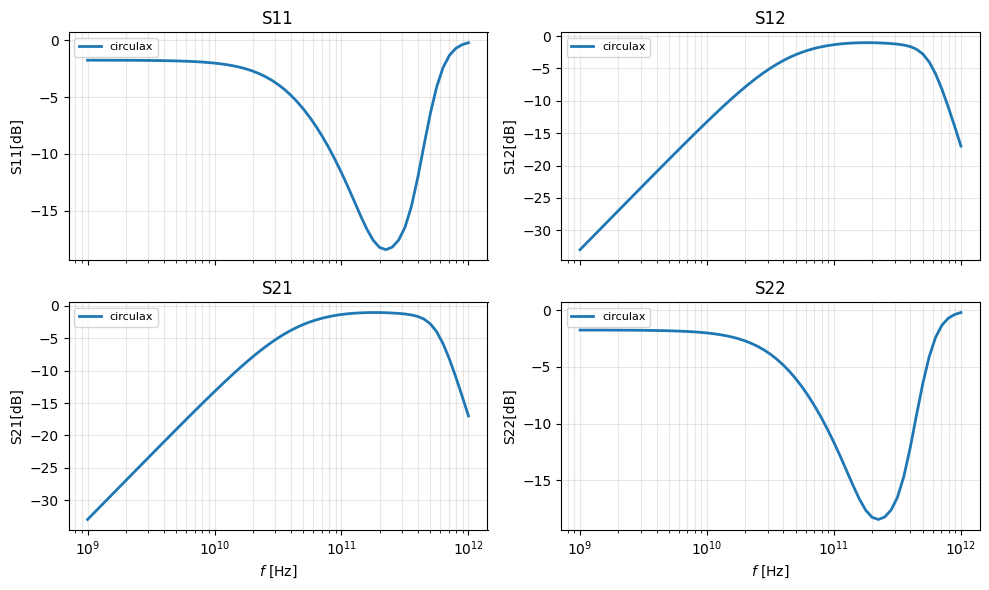

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

params = [(0, 0, "S11"), (0, 1, "S12"), (1, 0, "S21"), (1, 1, "S22")]
for i, j, label in params:
    ax = axes[i][j]
    ax.semilogx(
        freqs, 20 * jnp.log10(jnp.abs(S[:, i, j])), "C0", lw=2, label="circulax"
    )
    ax.set_title(label)
    ax.set_ylabel(label + "[dB]")
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel("$f$ [Hz]")

plt.tight_layout()
plt.show()

#### Plot Z-parameters

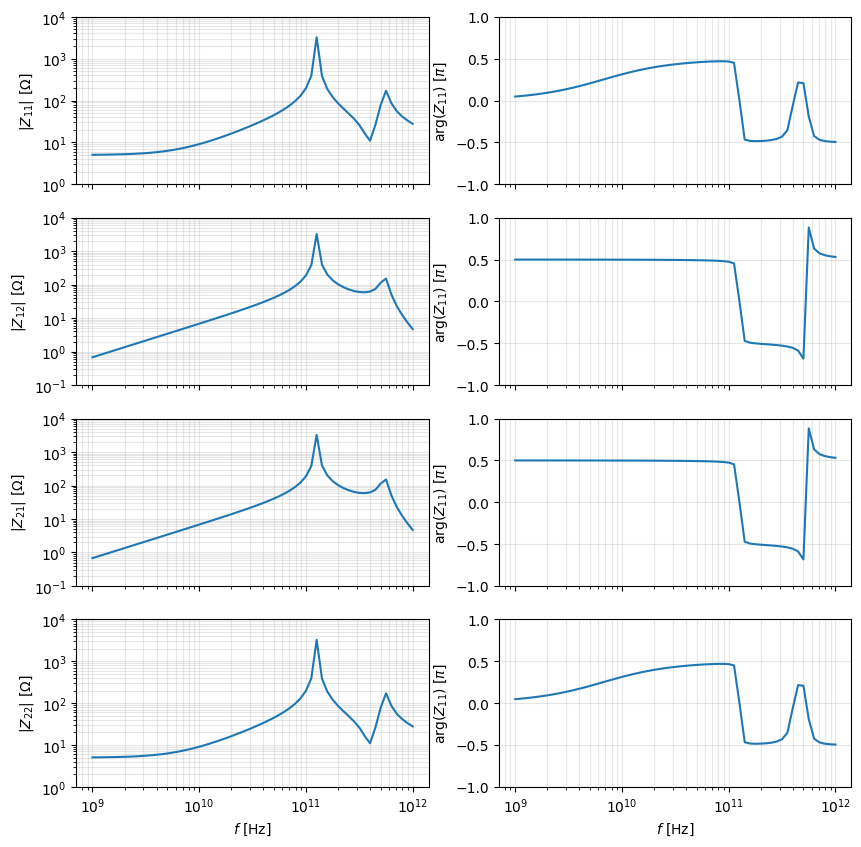

In [74]:
# calculate Z matrix
I = jnp.array([jnp.eye(2, 2)] * len(freqs))
Z = Z0 * jnp.linalg.solve(I - S, I + S)

fig, axes = plt.subplots(4, 2, figsize=(10, 10), sharex=True)

for i in range(4):
    j1 = int(jnp.floor(i / 2))
    j2 = int(i % 2)
    Zij = Z[:, j1, j2]

    ax = axes[i, 0]
    ax.loglog(freqs, jnp.abs(Zij), lw=1.5)
    ax.set_ylabel(r"$|Z_{" + f"{j1 + 1}{j2 + 1}" + r"}|$ [$\Omega$]")
    ax.grid(True, which="both", alpha=0.3)
    ax.set_ylim(
        10 ** jnp.floor(jnp.log10(jnp.min(jnp.abs(Zij)))),
        10 ** jnp.ceil(jnp.log10(jnp.max(jnp.abs(Zij)))),
    )
    if i == 3:
        ax.set_xlabel("$f$ [Hz]")

    # phase
    ax = axes[i, 1]
    ax.semilogx(freqs, jnp.angle(Zij) / jnp.pi, lw=1.5)
    ax.set_ylabel(r"arg$(Z_{11})$ [$\pi$]")
    ax.grid(True, which="both", alpha=0.3)
    ax.set_ylim(-1, 1)
    if i == 3:
        ax.set_xlabel("$f$ [Hz]")

## Parameter Extraction and Fit

The `circulax` model above uses carried-over parameters and a guessed coupling coefficient — it hasn't actually been fit to this transformer's Palace simulation yet. Next, we'll reduce the Palace results to the differential-mode target impedances ($Z_{dd11}$, $Z_{dd22}$, $Z_{dd12}$), treat the netlist's `L1, L2, M, Rs, Rp, C` as free parameters, and use JAX/`optax` to minimize the error between the model's and the simulation's differential impedances across frequency — recovering the physical inductance, coupling, and parasitic values that best reproduce the EM simulation.

Z12 == Z21: True


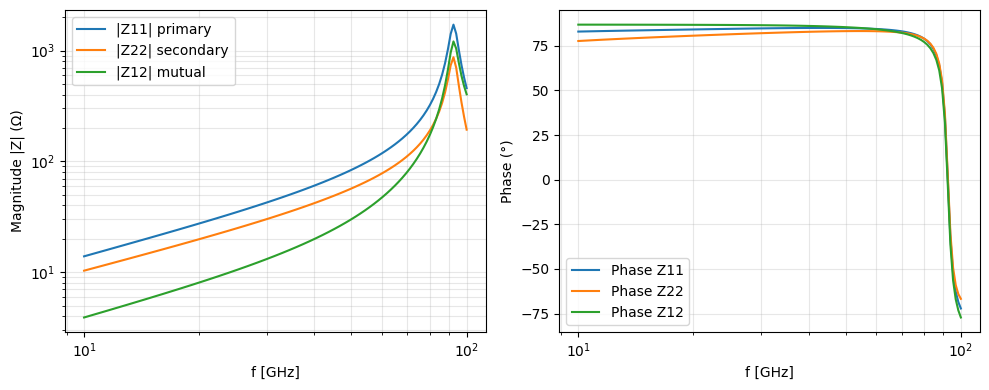

In [75]:
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf

# Extract frequencies and single-ended S-parameters from EM results
freq_scale = 1e9
f_sim = results.freq * freq_scale
ports = results.port_names
n = len(ports)

S = np.zeros((len(f_sim), n, n), dtype=complex)
for i, pi in enumerate(ports):
    for j, pj in enumerate(ports):
        S[:, i, j] = results[(pi, pj)].complex

# Convert to Z-parameters using scikit-rf
ntwk = rf.Network(f=f_sim, s=S, f_unit="hz")
Z = ntwk.z

# 3. Build the differential projection matrix (Mmix)
idx = {name: i for i, name in enumerate(ports)}
ip1, ip2 = idx["P1"], idx["P2"]
is1, is2 = idx["S1"], idx["S2"]

Mmix = np.zeros((2, n))
Mmix[0, ip1] = 1
Mmix[0, ip2] = -1  # primary loop
Mmix[1, is1] = 1
Mmix[1, is2] = -1  # secondary loop

# Project Single-Ended Z to Differential Z
Z_target = np.einsum("ai,fij,bj->fab", Mmix, Z, Mmix)

Z11 = Z_target[:, 0, 0]  # primary self-Z
Z22 = Z_target[:, 1, 1]  # secondary self-Z
Z12 = Z_target[:, 0, 1]  # mutual Z

# Ensure the transformer is reciprocal
print("Z12 == Z21:", np.allclose(Z_target[:, 0, 1], Z_target[:, 1, 0], rtol=1e-3))

# Plot the differential Z-parameters (Magnitude and Phase)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].loglog(f_sim / 1e9, np.abs(Z11), label="|Z11| primary")
ax[0].loglog(f_sim / 1e9, np.abs(Z22), label="|Z22| secondary")
ax[0].loglog(f_sim / 1e9, np.abs(Z12), label="|Z12| mutual")
ax[0].legend()
ax[0].set_xlabel("f [GHz]")
ax[0].set_ylabel("Magnitude |Z| (Ω)")
ax[0].grid(True, which="both", alpha=0.3)

ax[1].semilogx(f_sim / 1e9, np.angle(Z11, deg=True), label="Phase Z11")
ax[1].semilogx(f_sim / 1e9, np.angle(Z22, deg=True), label="Phase Z22")
ax[1].semilogx(f_sim / 1e9, np.angle(Z12, deg=True), label="Phase Z12")
ax[1].legend()
ax[1].set_xlabel("f [GHz]")
ax[1].set_ylabel("Phase (°)")
ax[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

In [76]:
n_lf = 5  # number of lowest-frequency points to average over
w_lf = w[:n_lf]

L1_ini = np.mean(np.imag(Z11[:n_lf]) / w_lf)
L2_ini = np.mean(np.imag(Z22[:n_lf]) / w_lf)
M_ini = np.mean(np.imag(Z_target[:n_lf, 0, 1]) / w_lf)
k_ini = M_ini / np.sqrt(L1_ini * L2_ini)

R1_ini = np.mean(np.real(Z11[:n_lf]))
R2_ini = np.mean(np.real(Z22[:n_lf]))
Rp_ini = 500.0

f0_1_ini = f_sim[np.argmax(np.abs(Z11))]
f0_2_ini = f_sim[np.argmax(np.abs(Z22))]

C1_ini = 1 / (L1_ini * (2 * np.pi * f0_1_ini) ** 2)
C2_ini = 1 / (L2_ini * (2 * np.pi * f0_2_ini) ** 2)

print(f"L1_ini = {L1_ini * 1e12:.3f} pH")
print(f"L2_ini = {L2_ini * 1e12:.3f} pH")
print(f"M_ini  = {M_ini * 1e12:.3f} pH")
print(f"k_ini  = {k_ini:.4f}")
print(f"R1_ini = {R1_ini:.4f} Ohm")
print(f"R2_ini = {R2_ini:.4f} Ohm")
print(f"f0_1_ini = {f0_1_ini / 1e9:.3f} GHz -> C1_ini = {C1_ini * 1e15:.4f} fF")
print(f"f0_2_ini = {f0_2_ini / 1e9:.3f} GHz -> C2_ini = {C2_ini * 1e15:.4f} fF")

L1_ini = 218.474 pH
L2_ini = 158.526 pH
M_ini  = 62.452 pH
k_ini  = 0.3356
R1_ini = 2.0365 Ohm
R2_ini = 2.5196 Ohm
f0_1_ini = 92.373 GHz -> C1_ini = 13.5879 fF
f0_2_ini = 92.373 GHz -> C2_ini = 18.7262 fF


In [119]:
from circulax.components.electronic import Capacitor, Resistor

net_dict = {
    "instances": {
        "GND": {"component": "ground"},
        "T1": {
            "component": "transformer",
            "settings": {
                "L1": L1_ini,
                "L2": L2_ini,
                "M": k_ini * np.sqrt(L1_ini * L2_ini),
            },
        },
        "R1": {"component": "resistor", "settings": {"R": R1_ini}},
        "R2": {"component": "resistor", "settings": {"R": R2_ini}},
        "C1": {"component": "capacitor", "settings": {"C": C1_ini}},
        "C2": {"component": "capacitor", "settings": {"C": C2_ini}},
        "Rp1": {"component": "resistor", "settings": {"R": Rp_ini}},
        "Rp2": {"component": "resistor", "settings": {"R": Rp_ini}},
    },
    "connections": {
        "R1,p1": "PORT_P1",
        "R1,p2": "T1,p1",
        "Rp1,p1": "T1,p1",
        "Rp1,p2": "C1,p1",
        "C1,p2": "T1,p2",
        "T1,p2": "GND,p1",
        "R2,p1": "PORT_S1",
        "R2,p2": "T1,s1",
        "Rp2,p1": "T1,s1",
        "Rp2,p2": "C2,p1",
        "C2,p2": "T1,s2",
        "T1,s2": "GND,p1",
    },
}

models = {
    "resistor": Resistor,
    "capacitor": Capacitor,
    "transformer": transformer,
    "inductor": Inductor,
    "ground": lambda: 0,
}

circuit = compile_circuit(net_dict, models)
groups = circuit.groups
print("Circuit compiled. System size:", circuit.sys_size)
print("Port map:", circuit.port_map)

port_nodes = [circuit.port_map["PORT_P1"], circuit.port_map["PORT_S1"]]
print("port_nodes:", port_nodes)

Circuit compiled. System size: 9
Port map: {'Rp1,p2': 1, 'C1,p1': 1, 'C2,p2': 0, 'T1,s2': 0, 'C1,p2': 0, 'GND,p1': 0, 'T1,p2': 0, 'C2,p1': 2, 'Rp2,p2': 2, 'R1,p1': 3, 'PORT_P1': 3, 'R2,p1': 4, 'PORT_S1': 4, 'T1,p1': 5, 'R1,p2': 5, 'Rp1,p1': 5, 'Rp2,p1': 6, 'T1,s1': 6, 'R2,p2': 6, 'T1,i_L1': 7, 'T1,i_L2': 8}
port_nodes: [3, 4]


In [162]:
from circulax.utils import update_params_dict


# Fitting setup: 9 params [L1,L2,k,R1,R2,C1,C2,Rp1,Rp2]
def positive(x):
    return jax.nn.softplus(x)


def inv_softplus(y):
    return jnp.log(jnp.expm1(y))


def unpack(raw_params):
    L1 = positive(raw_params[0]) * L1_ini
    L2 = positive(raw_params[1]) * L2_ini
    k = jnp.tanh(raw_params[2])
    R1 = positive(raw_params[3]) * R1_ini
    R2 = positive(raw_params[4]) * R2_ini
    C1 = positive(raw_params[5]) * C1_ini
    C2 = positive(raw_params[6]) * C2_ini
    Rp1 = positive(raw_params[7]) * Rp_ini
    Rp2 = positive(raw_params[8]) * Rp_ini
    return L1, L2, k, R1, R2, C1, C2, Rp1, Rp2


def z2s_2port(Z, z0=50.0):
    I = np.eye(2)
    Zn = Z / z0
    return np.array([np.linalg.solve(Zn[f] + I, Zn[f] - I) for f in range(Zn.shape[0])])


S_sim_diff = z2s_2port(Z_target, z0=50.0)
S_target_j = jnp.asarray(S_sim_diff)
freqs = jnp.asarray(f_sim)

lam_L = 0.001
lam_k = 0.001


def loss_circulax(raw_params):
    L1, L2, k, R1, R2, C1, C2, Rp1, Rp2 = unpack(raw_params)
    M = k * jnp.sqrt(L1 * L2)

    # 1. Update circuit parameters
    g = update_params_dict(groups, "transformer", "T1", "L1", L1)
    g = update_params_dict(g, "transformer", "T1", "L2", L2)
    g = update_params_dict(g, "transformer", "T1", "M", M)
    g = update_params_dict(g, "resistor", "R1", "R", R1)
    g = update_params_dict(g, "resistor", "R2", "R", R2)
    g = update_params_dict(g, "capacitor", "C1", "C", C1)
    g = update_params_dict(g, "capacitor", "C2", "C", C2)
    g = update_params_dict(g, "resistor", "Rp1", "R", Rp1)
    g = update_params_dict(g, "resistor", "Rp2", "R", Rp2)

    # 2. Run simulation
    y_op = circuit.with_groups(g)()
    ac = setup_ac_sweep(groups=g, num_vars=circuit.sys_size, port_nodes=port_nodes)
    S_cx = ac(freqs=freqs, y_dc=y_op)

    # 3. Calculate Complex Error (Replaces log-magnitude and wrapped phase)
    complex_err = S_cx - S_target_j

    # Square the absolute distance: |a + bj|^2 = a^2 + b^2
    # Splitting real and imag is much safer for JAX gradients than jnp.abs()
    err_sq = jnp.real(complex_err) ** 2 + jnp.imag(complex_err) ** 2

    # 4. Apply weighting and average
    w = jnp.array([[2.0, 1.0], [1.0, 2.0]])  # Kept your reflection upweighting
    data_loss = jnp.mean(w[None, :, :] * err_sq)

    # 5. Regularization
    reg_loss = (
        lam_L * ((L1 - L1_ini) / L1_ini) ** 2
        + lam_L * ((L2 - L2_ini) / L2_ini) ** 2
        + lam_k * (k - k_ini) ** 2
    )

    return data_loss + reg_loss


raw_one = inv_softplus(jnp.array(1.0))
raw_params_ini = jnp.array(
    [
        raw_one,
        raw_one,
        jnp.arctanh(jnp.array(k_ini)),
        raw_one,
        raw_one,
        raw_one,
        raw_one,
        raw_one,
        raw_one,
    ]
)

print("round-trip check:", unpack(raw_params_ini))

vg_fn = jax.jit(jax.value_and_grad(loss_circulax))

loss0, grads0 = vg_fn(raw_params_ini)
print("loss0:", float(loss0))
# print("grad0:", grads0) # Optional: comment out if it clutters the console

optimizer = optax.adam(1e-2)
raw_params = raw_params_ini
opt_state = optimizer.init(raw_params_ini)

n_steps = 8000
for step in range(n_steps):
    # FIX: Use the updated compiled function
    loss, grads = vg_fn(raw_params)

    if step % 1000 == 0:
        L1_, L2_, k_, R1_, R2_, C1_, C2_, Rp1_, Rp2_ = unpack(raw_params)
        print(
            f"step {step:5d}: L1={float(L1_) * 1e12:.2f}pH L2={float(L2_) * 1e12:.2f}pH "
            f"k={float(k_):.4f} R1={float(R1_):.3f} R2={float(R2_):.3f} "
            f"C1={float(C1_) * 1e15:.2f}fF C2={float(C2_) * 1e15:.2f}fF "
            f"Rp1={float(Rp1_):.1f} Rp2={float(Rp2_):.1f} loss={float(loss):.4e}"
        )

    updates, opt_state = optimizer.update(grads, opt_state)
    raw_params = optax.apply_updates(raw_params, updates)

L1_fit, L2_fit, k_fit, R1_fit, R2_fit, C1_fit, C2_fit, Rp1_fit, Rp2_fit = [
    float(x) for x in unpack(raw_params)
]

print("\n=== Final fitted parameters ===")
print(f"L1={L1_fit * 1e12:.3f}pH L2={L2_fit * 1e12:.3f}pH k={k_fit:.4f}")
print(
    f"R1={R1_fit:.4f} R2={R2_fit:.4f} C1={C1_fit * 1e15:.4f}fF C2={C2_fit * 1e15:.4f}fF"
)
print(f"Rp1={Rp1_fit:.2f} Rp2={Rp2_fit:.2f}")

round-trip check: (Array(2.18474319e-10, dtype=float64), Array(1.5852629e-10, dtype=float64), Array(0.33557872, dtype=float64), Array(2.03647567, dtype=float64), Array(2.51955154, dtype=float64), Array(1.35878545e-14, dtype=float64), Array(1.87262141e-14, dtype=float64), Array(500., dtype=float64), Array(500., dtype=float64))
loss0: 0.03495754224115108
step     0: L1=218.47pH L2=158.53pH k=0.3356 R1=2.036 R2=2.520 C1=13.59fF C2=18.73fF Rp1=500.0 Rp2=500.0 loss=3.4958e-02
step  1000: L1=204.25pH L2=146.60pH k=0.4409 R1=2.645 R2=3.356 C1=9.76fF C2=10.83fF Rp1=27.0 Rp2=31.2 loss=2.9487e-03
step  2000: L1=204.23pH L2=146.59pH k=0.4409 R1=2.647 R2=3.357 C1=9.77fF C2=10.83fF Rp1=26.8 Rp2=31.2 loss=2.9487e-03
step  3000: L1=204.23pH L2=146.59pH k=0.4409 R1=2.647 R2=3.357 C1=9.77fF C2=10.83fF Rp1=26.8 Rp2=31.2 loss=2.9487e-03
step  4000: L1=204.23pH L2=146.59pH k=0.4409 R1=2.647 R2=3.357 C1=9.77fF C2=10.83fF Rp1=26.8 Rp2=31.2 loss=2.9487e-03
step  5000: L1=204.23pH L2=146.59pH k=0.4409 R1=2.64

### Z parameters

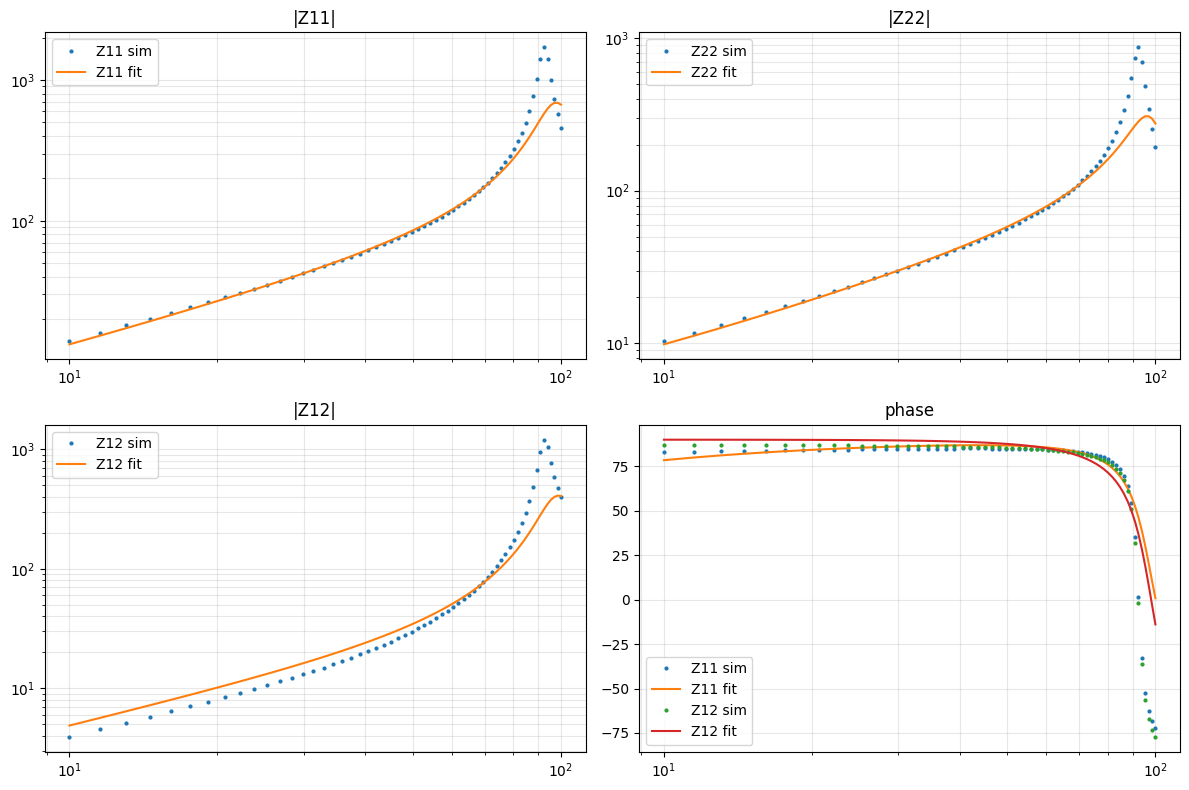

In [165]:
M_fit = k_fit * np.sqrt(L1_fit * L2_fit)

g_final = update_params_dict(groups, "transformer", "T1", "L1", L1_fit)
g_final = update_params_dict(g_final, "transformer", "T1", "L2", L2_fit)
g_final = update_params_dict(g_final, "transformer", "T1", "M", M_fit)
g_final = update_params_dict(g_final, "resistor", "R1", "R", R1_fit)
g_final = update_params_dict(g_final, "resistor", "R2", "R", R2_fit)
g_final = update_params_dict(g_final, "capacitor", "C1", "C", C1_fit)
g_final = update_params_dict(g_final, "capacitor", "C2", "C", C2_fit)
g_final = update_params_dict(g_final, "resistor", "Rp1", "R", Rp1_fit)
g_final = update_params_dict(g_final, "resistor", "Rp2", "R", Rp2_fit)

y_final = circuit.with_groups(g_final)()
ac_final = setup_ac_sweep(
    groups=g_final, num_vars=circuit.sys_size, port_nodes=port_nodes
)
S_final = ac_final(freqs=freqs, y_dc=y_final)


def s2z_2port(S, z0=50.0):
    I = np.eye(2)
    # S has shape (N_freqs, 2, 2)
    return np.array(
        [z0 * np.linalg.solve(I - S[f], I + S[f]) for f in range(S.shape[0])]
    )


Z_final = s2z_2port(S_final)
Z_fit_np = np.array(Z_final)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].loglog(f_sim / 1e9, np.abs(Z_target[:, 0, 0]), ".", ms=4, label="Z11 sim")
axes[0, 0].loglog(f_sim / 1e9, np.abs(Z_final[:, 0, 0]), label="Z11 fit")
axes[0, 0].legend()
axes[0, 0].set_title("|Z11|")
axes[0, 0].grid(True, which="both", alpha=0.3)

axes[0, 1].loglog(f_sim / 1e9, np.abs(Z_target[:, 1, 1]), ".", ms=4, label="Z22 sim")
axes[0, 1].loglog(f_sim / 1e9, np.abs(Z_final[:, 1, 1]), label="Z22 fit")
axes[0, 1].legend()
axes[0, 1].set_title("|Z22|")
axes[0, 1].grid(True, which="both", alpha=0.3)

axes[1, 0].loglog(f_sim / 1e9, np.abs(Z_target[:, 0, 1]), ".", ms=4, label="Z12 sim")
axes[1, 0].loglog(f_sim / 1e9, np.abs(Z_final[:, 0, 1]), label="Z12 fit")
axes[1, 0].legend()
axes[1, 0].set_title("|Z12|")
axes[1, 0].grid(True, which="both", alpha=0.3)

axes[1, 1].semilogx(
    f_sim / 1e9, np.angle(Z_target[:, 0, 0], deg=True), ".", ms=4, label="Z11 sim"
)
axes[1, 1].semilogx(f_sim / 1e9, np.angle(Z_final[:, 0, 0], deg=True), label="Z11 fit")
axes[1, 1].semilogx(
    f_sim / 1e9, np.angle(Z_target[:, 0, 1], deg=True), ".", ms=4, label="Z12 sim"
)
axes[1, 1].semilogx(f_sim / 1e9, np.angle(Z_final[:, 0, 1], deg=True), label="Z12 fit")
axes[1, 1].legend()
axes[1, 1].set_title("phase")
axes[1, 1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

### S parameters

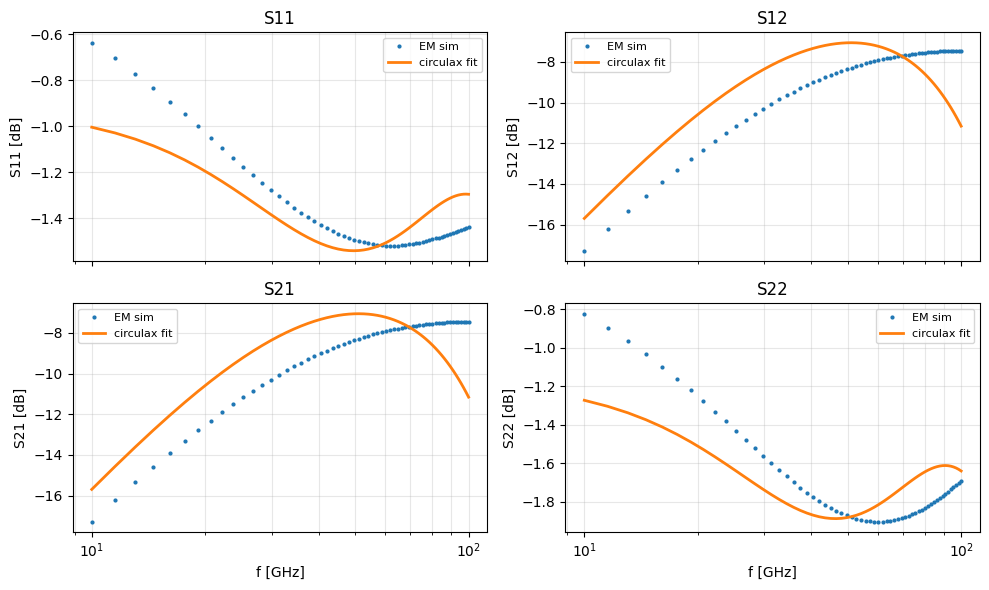

Param     RMSE (dB)   Max err (dB)
S11           0.135          0.367
S12           1.720          3.716
S21           1.720          3.716
S22           0.180          0.449


In [166]:
# S_final IS the differential S-parameters already — use it directly, no conversion
S_fit_np = np.array(S_final)
S_sim_np = np.array(
    S_target_j
)  # this is the true differential S from EM sim, already computed earlier

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
params = [(0, 0, "S11"), (0, 1, "S12"), (1, 0, "S21"), (1, 1, "S22")]
for i, j, label in params:
    ax = axes[i][j]
    ax.semilogx(
        f_sim / 1e9, 20 * np.log10(np.abs(S_sim_np[:, i, j])), ".", ms=4, label="EM sim"
    )
    ax.semilogx(
        f_sim / 1e9,
        20 * np.log10(np.abs(S_fit_np[:, i, j])),
        lw=2,
        label="circulax fit",
    )
    ax.set_title(label)
    ax.set_ylabel(label + " [dB]")
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)
for ax in axes[1]:
    ax.set_xlabel("f [GHz]")
plt.tight_layout()
plt.show()

err_db = 20 * np.log10(np.abs(S_fit_np)) - 20 * np.log10(np.abs(S_sim_np))
print(f"{'Param':6s} {'RMSE (dB)':>12s} {'Max err (dB)':>14s}")
for i, j, label in params:
    rmse = np.sqrt(np.mean(err_db[:, i, j] ** 2))
    max_err = np.max(np.abs(err_db[:, i, j]))
    print(f"{label:6s} {rmse:12.3f} {max_err:14.3f}")